In [8]:
import os
import numpy as np


def read_points_from_dat(path):
    """Đọc tọa độ từ file .dat theo đúng format trong C_Version/Function.cpp."""
    with open(path, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines:
        raise ValueError(f'File rỗng: {path}')

    first_tokens = lines[0].split()
    parameterized = len(first_tokens) > 0 and first_tokens[0] == 'number_truck'

    start_idx = 0
    if parameterized:
        # 7 dòng tham số + 1 dòng header
        start_idx = 8
    else:
        # Nếu dòng đầu không phải số thì xem như header
        try:
            float(first_tokens[0])
            start_idx = 0
        except (ValueError, IndexError):
            start_idx = 1

    points = []
    for line in lines[start_idx:]:
        toks = line.split()
        if len(toks) < 4:
            continue
        x = float(toks[0])
        y = float(toks[1])
        points.append([x, y])

    if len(points) == 0:
        raise ValueError(f'Không đọc được điểm nào từ file: {path}')

    return np.array(points, dtype=float)


def init_group_stats():
    return {
        'avg_dist_to_depot_list': [],
        'avg_dist_between_points_list': [],
        'std_dist_to_depot_list': [],
        'std_dist_between_points_list': [],
        'max_dist_to_depot_list': [],
        'max_dist_between_points_list': [],
        'files': []
    }


def get_group_from_filename(filename):
    # Kiểm tra RC101 trước để không bị match nhầm vào R101/C101
    for group in ['RC101', 'C101', 'C201', 'R101']:
        if filename.startswith(group):
            return group
    return None


def update_group_stats(stats, data, filename):
    depot = data[0]
    points = data[1:]

    stats['files'].append(filename)

    if points.shape[0] == 0:
        stats['avg_dist_to_depot_list'].append(0.0)
        stats['std_dist_to_depot_list'].append(0.0)
        stats['avg_dist_between_points_list'].append(0.0)
        stats['std_dist_between_points_list'].append(0.0)
        stats['max_dist_to_depot_list'].append(0.0)
        stats['max_dist_between_points_list'].append(0.0)
        return

    # Khoảng cách Euclid (nhất quán với drone_time trong Function.cpp)
    dists_to_depot = np.linalg.norm(points - depot, axis=1)
    stats['avg_dist_to_depot_list'].append(np.mean(dists_to_depot))
    stats['std_dist_to_depot_list'].append(np.std(dists_to_depot))
    stats['max_dist_to_depot_list'].append(np.max(dists_to_depot))

    n = points.shape[0]
    if n > 1:
        diff = points[:, None, :] - points[None, :, :]
        dist_matrix = np.linalg.norm(diff, axis=2)
        upper_i, upper_j = np.triu_indices(n, k=1)
        dists_between_points = dist_matrix[upper_i, upper_j]
        stats['avg_dist_between_points_list'].append(np.mean(dists_between_points))
        stats['std_dist_between_points_list'].append(np.std(dists_between_points))
        stats['max_dist_between_points_list'].append(np.max(dists_between_points))
    else:
        stats['avg_dist_between_points_list'].append(0.0)
        stats['std_dist_between_points_list'].append(0.0)
        stats['max_dist_to_depot_list'].append(0.0)
        stats['max_dist_between_points_list'].append(0.0)


def print_group_statistics(group_name, stats):
    if len(stats['files']) == 0:
        print(f'\nNhóm {group_name}: không có file')
        return

    print(f'\n=== Nhóm {group_name} ({len(stats["files"])} file) ===')
    print('Khoảng cách trung bình tới depot:', np.mean(stats['avg_dist_to_depot_list']))
    print('Khoảng cách tối đa các điểm tới depot:', np.max(stats['max_dist_to_depot_list']))
    print('Độ lệch chuẩn trung bình tới depot:', np.mean(stats['std_dist_to_depot_list']))
    
    print('Khoảng cách tối đa giữa các điểm:', np.max(stats['max_dist_between_points_list']))
    print('Khoảng cách trung bình giữa các điểm:', np.mean(stats['avg_dist_between_points_list']))
    print('Độ lệch chuẩn trung bình giữa các điểm:', np.mean(stats['std_dist_between_points_list']))

def compute_statistics_by_group(folder_path):
    dat_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.dat')])
    if not dat_files:
        raise ValueError(f'Không có file .dat trong thư mục: {folder_path}')

    groups = {
        'C101': init_group_stats(),
        'C201': init_group_stats(),
        'R101': init_group_stats(),
        'RC101': init_group_stats(),
    }

    ignored_files = []

    for filename in dat_files:
        group = get_group_from_filename(filename)
        if group is None:
            ignored_files.append(filename)
            continue

        file_path = os.path.join(folder_path, filename)
        data = read_points_from_dat(file_path)
        update_group_stats(groups[group], data, filename)

    print('Tổng số file .dat đã quét:', len(dat_files))
    print('Số file dùng để thống kê 4 nhóm:', sum(len(groups[g]['files']) for g in groups))

    for group_name in ['C101', 'C201', 'R101', 'RC101']:
        print_group_statistics(group_name, groups[group_name])

    if ignored_files:
        print('\nFile không thuộc 4 nhóm (bỏ qua):')
        for name in ignored_files:
            print('-', name)


compute_statistics_by_group('test_data/data_demand_random_50_batch_all1_equal_cluster')


Tổng số file .dat đã quét: 24
Số file dùng để thống kê 4 nhóm: 24

=== Nhóm C101 (6 file) ===
Khoảng cách trung bình tới depot: 24.114638385342392
Khoảng cách tối đa các điểm tới depot: 41.23105625617661
Độ lệch chuẩn trung bình tới depot: 9.358643894505827
Khoảng cách tối đa giữa các điểm: 57.0087712549569
Khoảng cách trung bình giữa các điểm: 26.559697087149456
Độ lệch chuẩn trung bình giữa các điểm: 13.825635787354566

=== Nhóm C201 (6 file) ===
Khoảng cách trung bình tới depot: 26.793729217974317
Khoảng cách tối đa các điểm tới depot: 41.23105625617661
Độ lệch chuẩn trung bình tới depot: 9.140901191560353
Khoảng cách tối đa giữa các điểm: 70.77428911688199
Khoảng cách trung bình giữa các điểm: 30.753572215405203
Độ lệch chuẩn trung bình giữa các điểm: 15.255799836289095

=== Nhóm R101 (6 file) ===
Khoảng cách trung bình tới depot: 26.24751880295005
Khoảng cách tối đa các điểm tới depot: 43.93176527297759
Độ lệch chuẩn trung bình tới depot: 9.39828477376503
Khoảng cách tối đa giữa c

In [10]:
import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


def read_distance_and_release_from_dat(path):
    """Đọc (distance_to_depot, release_date) cho từng điểm khách hàng từ file .dat."""
    with open(path, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines:
        raise ValueError(f'File rỗng: {path}')

    first_tokens = lines[0].split()
    parameterized = len(first_tokens) > 0 and first_tokens[0] == 'number_truck'

    if parameterized:
        data_start = 8
    else:
        try:
            float(first_tokens[0])
            data_start = 0
        except (ValueError, IndexError):
            data_start = 1

    rows = []
    for line in lines[data_start:]:
        toks = line.split()
        if len(toks) < 4:
            continue
        x = float(toks[0])
        y = float(toks[1])
        release = float(toks[3])
        rows.append((x, y, release))

    if len(rows) <= 1:
        return np.array([]), np.array([])

    # Dòng đầu tiên là depot
    depot_x, depot_y, _ = rows[0]
    customer_rows = rows[1:]

    distances = np.array([
        np.hypot(x - depot_x, y - depot_y) for x, y, _ in customer_rows
    ], dtype=float)
    releases = np.array([r for _, _, r in customer_rows], dtype=float)

    return distances, releases


def extract_beta(filename):
    # Ví dụ: C101_0.5.dat -> beta = 0.5
    base = os.path.splitext(filename)[0]
    if '_' not in base:
        return None
    beta_text = base.rsplit('_', 1)[-1]
    try:
        return float(beta_text)
    except ValueError:
        return None


def correlation_by_beta(folder_path):
    beta_to_dist = {}
    beta_to_release = {}

    dat_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.dat')])
    if not dat_files:
        raise ValueError(f'Không có file .dat trong thư mục: {folder_path}')

    for filename in dat_files:
        beta = extract_beta(filename)
        if beta is None:
            continue

        distances, releases = read_distance_and_release_from_dat(os.path.join(folder_path, filename))
        if distances.size == 0:
            continue

        beta_to_dist.setdefault(beta, []).append(distances)
        beta_to_release.setdefault(beta, []).append(releases)

    betas = sorted(beta_to_dist.keys())
    if not betas:
        raise ValueError('Không trích xuất được beta hợp lệ từ tên file.')

    corr_values = []
    point_counts = []

    print('Hệ số tương quan (Pearson) giữa khoảng cách tới depot và release date theo từng beta:')
    for beta in betas:
        dist_all = np.concatenate(beta_to_dist[beta])
        rel_all = np.concatenate(beta_to_release[beta])

        std_dist = np.std(dist_all)
        std_rel = np.std(rel_all)
        if std_dist == 0 or std_rel == 0:
            corr = 0.0
        else:
            corr = np.corrcoef(dist_all, rel_all)[0, 1]
        corr_values.append(corr)
        point_counts.append(len(dist_all))

        print(f'beta = {beta:<3}: correlation = {corr:.6f} (n_points = {len(dist_all)})')

    plt.figure(figsize=(8, 4.5))
    plt.plot(betas, corr_values, marker='o', linewidth=2)
    plt.title('Correlation(distance to depot, release date) theo beta')
    plt.xlabel('beta')
    plt.ylabel('correlation')
    plt.grid(True, alpha=0.3)
    plt.xticks(betas)
    plt.tight_layout()
    output_plot = os.path.join(folder_path, 'correlation_by_beta.png')
    plt.savefig(output_plot, dpi=150)
    plt.close()
    print(f'Đã lưu biểu đồ: {output_plot}')

    return betas, corr_values, point_counts


print('\n=== equal_random ===')
correlation_by_beta('test_data/data_demand_random_50_batch_all1_equal_random')
print('\n=== equal_cluster ===')
correlation_by_beta('test_data/data_demand_random_50_batch_all1_equal_cluster')



=== equal_random ===
Hệ số tương quan (Pearson) giữa khoảng cách tới depot và release date theo từng beta:
beta = 0.5: correlation = 0.083262 (n_points = 200)
beta = 1.0: correlation = -0.039152 (n_points = 200)
beta = 1.5: correlation = 0.006902 (n_points = 200)
beta = 2.0: correlation = 0.070299 (n_points = 200)
beta = 2.5: correlation = 0.127208 (n_points = 200)
beta = 3.0: correlation = 0.056520 (n_points = 200)
Đã lưu biểu đồ: test_data/data_demand_random_50_batch_all1_equal_random/correlation_by_beta.png

=== equal_cluster ===
Hệ số tương quan (Pearson) giữa khoảng cách tới depot và release date theo từng beta:
beta = 0.5: correlation = 0.619709 (n_points = 200)
beta = 1.0: correlation = 0.619526 (n_points = 200)
beta = 1.5: correlation = 0.594255 (n_points = 200)
beta = 2.0: correlation = 0.629766 (n_points = 200)
beta = 2.5: correlation = 0.607105 (n_points = 200)
beta = 3.0: correlation = 0.606608 (n_points = 200)
Đã lưu biểu đồ: test_data/data_demand_random_50_batch_all1_equ

([0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
 [0.6197094017010767,
  0.6195262724829427,
  0.5942551436210003,
  0.629765758896448,
  0.6071052700709739,
  0.6066077628307406],
 [200, 200, 200, 200, 200, 200])

/var/folders/2f/w71j3hts4vnbys4q5817ljg80000gn/T/ipykernel_41452/3718472691.py:35: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  route_xy = points[route_points]


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

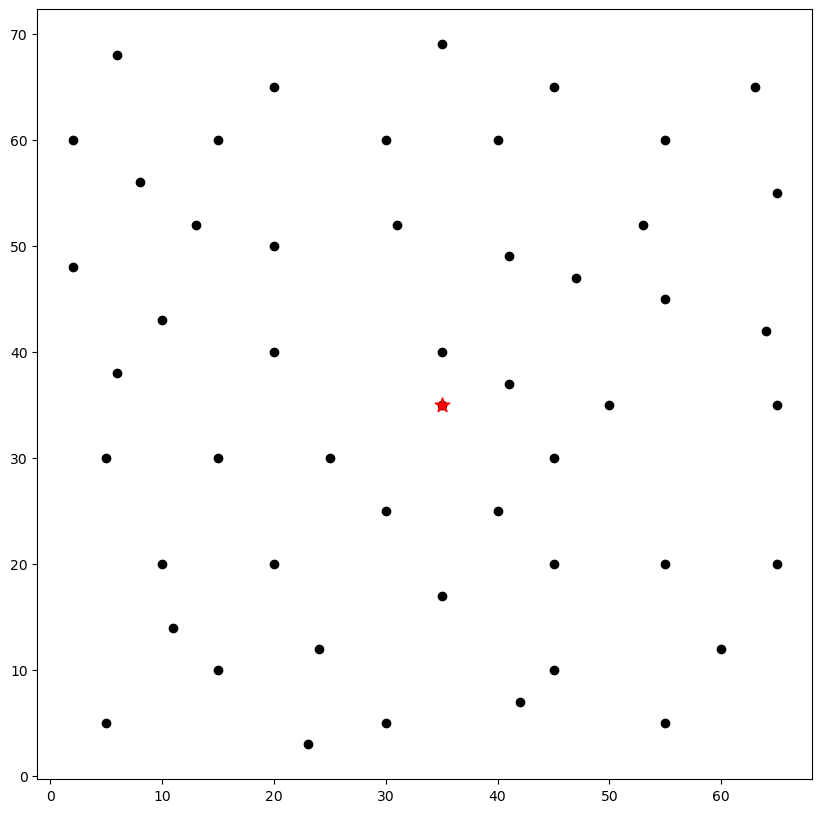

In [1]:
import ast
import matplotlib.pyplot as plt
import numpy as np

# 1. Đọc tọa độ các điểm từ file .dat
points = []
with open("test_data/data_demand_random/50/R101_1.5.dat") as f:
    lines = [line.strip() for line in f if line.strip()]
    # Bỏ qua 8 dòng đầu (header + params)
    for line in lines[8:]:
        toks = line.split()
        if len(toks) >= 2:
            x, y = float(toks[0]), float(toks[1])
            points.append([x, y])
points = np.array(points)

# 2. Chuỗi solution từ dòng 237 (copy từ summary_f3_recomputed_2.csv)
solution_str = "[[[[0,[28,18,7,11,19,47,49,36,46,16,13,2,4,50,1,10,31]],[28,[]],[18,[]],[7,[]],[11,[]],[19,[]],[48,[48,8,45,21]],[47,[]],[49,[]],[36,[]],[46,[]],[8,[]],[45,[]],[16,[32,12,27,44]],[44,[]],[42,[42,37]],[37,[]],[13,[]],[2,[]],[21,[]],[4,[]],[12,[]],[50,[]],[1,[]],[30,[20,30]],[20,[]],[32,[]],[10,[]],[31,[]],[27,[]]],[[0,[40,26,3,33,9,35,34,29,24,25,39,23,22,41,15,43,14,38,17,5,6]],[40,[]],[26,[]],[3,[]],[33,[]],[9,[]],[35,[]],[34,[]],[29,[]],[24,[]],[25,[]],[39,[]],[23,[]],[22,[]],[41,[]],[15,[]],[43,[]],[14,[]],[38,[]],[17,[]],[5,[]],[6,[]]]],[[[48,[48,8,45,21]]],[[16,[32,12,27,44]]],[[42,[42,37]]],[[30,[20,30]]]]]"

# 3. Parse solution
sol = ast.literal_eval(solution_str)
truck_routes = sol[0]  # 2 truck routes
# drone_trips = sol[1]  # các chuyến drone (nếu cần)

# 4. Vẽ các tuyến truck
plt.figure(figsize=(10, 10))
plt.scatter(points[:, 0], points[:, 1], c="black", label="Khách hàng")
plt.scatter(points[0, 0], points[0, 1], c="red", s=120, marker="*", label="Depot")

colors = ["blue", "green", "orange", "purple"]
for idx, route in enumerate(truck_routes):
    if len(route) < 2:
        continue
    route_points = [0] + route[1] + [0] if route[0] == 0 else route[1]
    route_xy = points[route_points]
    plt.plot(route_xy[:, 0], route_xy[:, 1], '-', color=colors[idx % len(colors)], label=f"Truck {idx+1}")
    plt.scatter(route_xy[:, 0], route_xy[:, 1], color=colors[idx % len(colors)])

plt.title("Best Solution dòng 237 - R101_1.5.dat")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Đọc lại tọa độ và release date các điểm
points = []
releases = []
with open("test_data/data_demand_random/50/R101_1.5.dat") as f:
    lines = [line.strip() for line in f if line.strip()]
    for line in lines[8:]:
        toks = line.split()
        if len(toks) >= 4:
            x, y, _, release = float(toks[0]), float(toks[1]), float(toks[2]), float(toks[3])
            points.append([x, y])
            releases.append(release)
points = np.array(points)
releases = np.array(releases)

plt.figure(figsize=(10, 10))
sc = plt.scatter(points[:, 0], points[:, 1], c=releases, cmap="viridis", s=80, label="Khách hàng")
plt.scatter(points[0, 0], points[0, 1], c="red", s=120, marker="*", label="Depot")
plt.colorbar(sc, label="Release date")
plt.title("Release date của các điểm - R101_1.5.dat")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

# Quick visualize: Truck routes + Drone trip paths + package order/release labels
# Usage: set instance_path and solution_text, then Run All.

import ast
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


def visualize_solution(instance_path, solution_text, output_path=None, show=True, annotate_nodes=True):
    instance_path = Path(instance_path)
    if output_path is None:
        output_path = instance_path.with_suffix('')
        output_path = output_path.parent / f"{output_path.name}_visualized.png"
    else:
        output_path = Path(output_path)

    solution = ast.literal_eval(solution_text)
    truck_part = solution[0]
    drone_part = solution[1]

    lines = [ln.strip() for ln in instance_path.read_text().splitlines() if ln.strip()]
    start = next(i for i, l in enumerate(lines) if l.startswith('XCOORD')) + 1
    coords = {}
    release = {}
    for idx, ln in enumerate(lines[start:]):
        x, y, d, rd = ln.split()[:4]
        coords[idx] = (float(x), float(y))
        release[idx] = int(float(rd))

    customers = [n for n in coords if n != 0]
    rels = sorted({release[n] for n in customers})
    rel_to_idx = {r: i for i, r in enumerate(rels)}

    fig, ax = plt.subplots(figsize=(16, 12))
    xs = [coords[n][0] for n in customers]
    ys = [coords[n][1] for n in customers]
    cs = [rel_to_idx[release[n]] for n in customers]
    sc = ax.scatter(xs, ys, c=cs, cmap='viridis', s=65, edgecolors='k', linewidths=0.3, zorder=2)

    ax.scatter([coords[0][0]], [coords[0][1]], marker='s', s=260, c='red', edgecolors='black', zorder=7, label='Depot (0)')
    ax.text(coords[0][0] + 0.4, coords[0][1] + 0.4, '0', fontsize=10, fontweight='bold')

    if annotate_nodes:
        for n in customers:
            x, y = coords[n]
            ax.text(x + 0.30, y + 0.30, f'{n}(r={release.get(n, "?")})', fontsize=7, alpha=0.9)

    truck_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i, route_data in enumerate(truck_part, 1):
        route = [stop[0] for stop in route_data]
        col = truck_colors[(i - 1) % len(truck_colors)]
        for a, b in zip(route[:-1], route[1:]):
            arr = FancyArrowPatch(coords[a], coords[b], arrowstyle='->', mutation_scale=9,
                                  linewidth=2.0, color=col, alpha=0.92, zorder=3)
            ax.add_patch(arr)
        ax.plot([], [], color=col, linewidth=2.0, label=f'Truck {i}')

    trip_colors = ['#d81b60', '#8e24aa', '#00897b', '#6d4c41', '#3949ab', '#f4511e']
    for t_idx, trip in enumerate(drone_part, 1):
        launches = [ev[0] for ev in trip]
        path = [0] + launches + [0]
        col = trip_colors[(t_idx - 1) % len(trip_colors)]

        for a, b in zip(path[:-1], path[1:]):
            arr = FancyArrowPatch(coords[a], coords[b], arrowstyle='-|>', mutation_scale=9,
                                  linewidth=1.9, color=col, alpha=0.9,
                                  linestyle=(0, (4, 2)), zorder=5)
            ax.add_patch(arr)

        for launch, pkgs in trip:
            if not pkgs:
                continue
            lines_txt = []
            for k, p in enumerate(pkgs, 1):
                rd = release.get(p, '?')
                lines_txt.append(f'{k}.{p} [r={rd}]')
            note = 'T' + str(t_idx) + ' @' + str(launch) + '\n' + '; '.join(lines_txt)
            lx, ly = coords[launch]
            ax.text(lx + 0.6, ly - 1.2, note, fontsize=8, color=col,
                    bbox=dict(facecolor='white', edgecolor=col, alpha=0.88, boxstyle='round,pad=0.25'),
                    zorder=8)

        ax.plot([], [], color=col, linestyle=(0, (4, 2)), linewidth=1.9,
                label=f'Drone trip {t_idx}: ' + '-'.join(map(str, path)))

    cbar = plt.colorbar(sc, ax=ax, fraction=0.045, pad=0.02)
    step = max(1, len(rels) // 8)
    ticks = list(range(0, len(rels), step))
    if ticks[-1] != len(rels) - 1:
        ticks.append(len(rels) - 1)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([str(rels[t]) for t in ticks])
    cbar.set_label('Customer release date')

    ax.set_title(f'Visualization: {instance_path.name}')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.grid(True, alpha=0.2)
    ax.legend(loc='upper left', fontsize=8)
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.savefig(output_path, dpi=220)

    print('saved:', output_path)
    for t_idx, trip in enumerate(drone_part, 1):
        print('trip', t_idx, ':', [0] + [ev[0] for ev in trip] + [0])

    if show:
        plt.show()
    else:
        plt.close(fig)


# =========================
# Example (edit these vars)
# =========================
instance_path = 'test_data/data_demand_random_50_batch_all1_equal_cluster/R101_1.5.dat'

solution_text = r"""[[[[0,[5]],[18,[18]],[5,[24,22,21,20,19,23]],[7,[7]],[13,[13]],[23,[]],[22,[]],[24,[]],[21,[]],[20,[33,32,34,31,30,35,37]],[19,[]],[35,[]],[37,[]],[38,[38]],[41,[45,48,47,46,41]],[33,[]],[32,[]],[45,[]],[48,[]],[47,[]],[46,[]],[34,[]],[31,[]],[30,[]]],[[0,[2,3,1,4]],[2,[]],[3,[]],[8,[8,12,6,9,10,11]],[1,[]],[12,[]],[4,[17,15,16,14]],[17,[]],[15,[]],[16,[]],[25,[25]],[26,[26,27,28,29]],[27,[]],[28,[]],[29,[]],[14,[]],[40,[40,36,44]],[36,[]],[6,[]],[9,[42,39,43,50,49]],[43,[]],[42,[]],[39,[]],[44,[]],[10,[]],[11,[]],[50,[]],[49,[]]]],[[[18,[18]]],[[8,[8,12,6,9,10,11]]],[[5,[24,22,21,20,19,23]]],[[4,[17,15,16,14]],[7,[7]]],[[25,[25]],[13,[13]]],[[26,[26,27,28,29]]],[[20,[33,32,34,31,30,35,37]]],[[40,[40,36,44]],[38,[38]]],[[9,[42,39,43,50,49]]],[[41,[45,48,47,46,41]]]]]"""

output_path = '/Users/huetran/CheckzingHueTT/result/Question4,14/visualize_R101_1.5_4_120.png'
visualize_solution(instance_path, solution_text, output_path=output_path, show=True, annotate_nodes=True)


Saved: /Users/huetran/CheckzingHueTT/result/Question4,14/C201_2.5_A8_L120.png
Drone trip 1:  [0, 10, 9, 0]
Drone trip 2:  [0, 8, 0]
Drone trip 3:  [0, 4, 17, 0]
Drone trip 4:  [0, 18, 0]
Drone trip 5:  [0, 20, 15, 0]
Drone trip 6:  [0, 21, 14, 0]
Drone trip 7:  [0, 32, 0]
Drone trip 8:  [0, 40, 0]
Drone trip 9:  [0, 38, 0]
Drone trip 10:  [0, 44, 50, 0]
Drone trip 11:  [0, 48, 0]


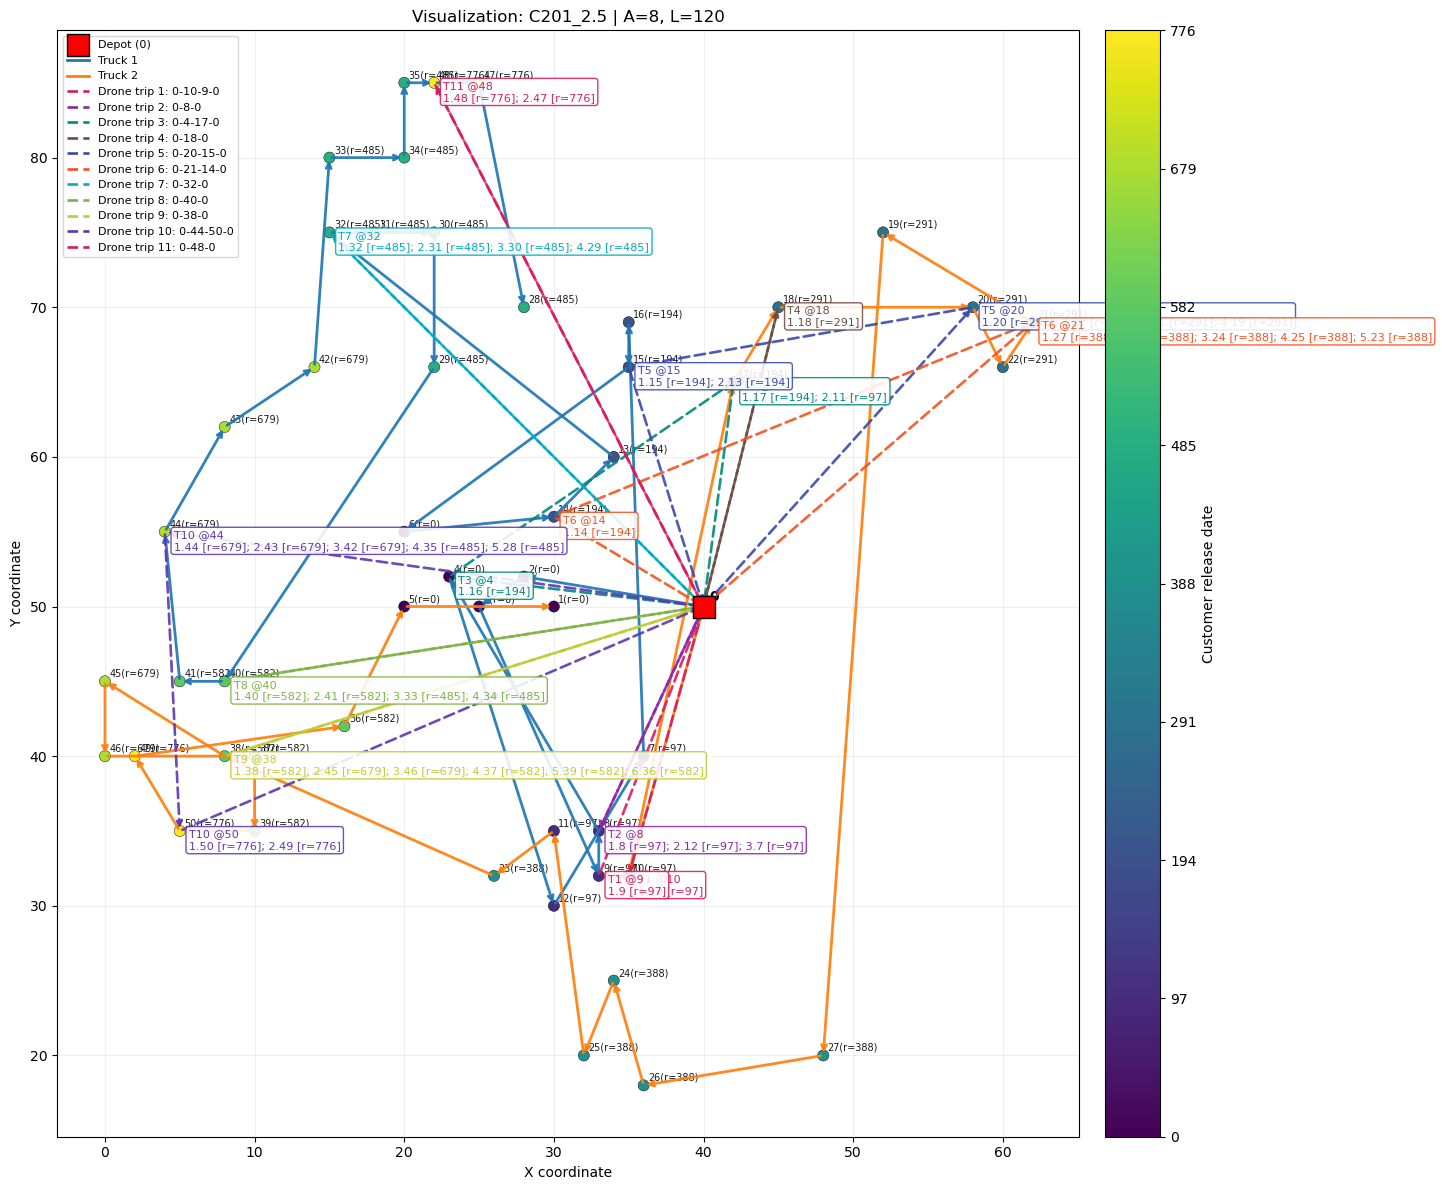

In [3]:
import ast
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


def visualize_solution(instance_path, solution_text, A, L, show=True, annotate_nodes=True):
    """
    instance_path : đường dẫn file instance .dat
    solution_text : chuỗi nghiệm
    A             : payload/capacity, ví dụ 4
    L             : endurance, ví dụ 120
    """

    # ====== Thư mục output cố định ======
    output_dir = Path("/Users/huetran/CheckzingHueTT/result/Question4,14/")
    output_dir.mkdir(parents=True, exist_ok=True)

    # ====== Xử lý tên file output ======
    instance_path = Path(instance_path)
    instance_name = instance_path.stem   # ví dụ: R101_1.5
    output_path = output_dir / f"{instance_name}_A{A}_L{L}.png"

    # ====== Đọc nghiệm ======
    solution = ast.literal_eval(solution_text)
    truck_part = solution[0]
    drone_part = solution[1]

    # ====== Đọc dữ liệu instance ======
    lines = [ln.strip() for ln in instance_path.read_text().splitlines() if ln.strip()]
    start = next(i for i, l in enumerate(lines) if l.startswith("XCOORD")) + 1

    coords = {}
    release = {}

    for idx, ln in enumerate(lines[start:]):
        x, y, d, rd = ln.split()[:4]
        coords[idx] = (float(x), float(y))
        release[idx] = int(float(rd))

    customers = [n for n in coords if n != 0]
    rels = sorted({release[n] for n in customers})
    rel_to_idx = {r: i for i, r in enumerate(rels)}

    # ====== Vẽ ======
    fig, ax = plt.subplots(figsize=(16, 12))

    xs = [coords[n][0] for n in customers]
    ys = [coords[n][1] for n in customers]
    cs = [rel_to_idx[release[n]] for n in customers]

    sc = ax.scatter(
        xs, ys,
        c=cs, cmap="viridis",
        s=65, edgecolors="k", linewidths=0.3, zorder=2
    )

    # Depot
    ax.scatter(
        [coords[0][0]], [coords[0][1]],
        marker="s", s=260, c="red", edgecolors="black",
        zorder=7, label="Depot (0)"
    )
    ax.text(coords[0][0] + 0.4, coords[0][1] + 0.4, "0", fontsize=10, fontweight="bold")

    # Ghi nhãn node
    if annotate_nodes:
        for n in customers:
            x, y = coords[n]
            ax.text(x + 0.30, y + 0.30, f"{n}(r={release.get(n, '?')})", fontsize=7, alpha=0.9)

    # ====== Truck routes ======
    truck_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for i, route_data in enumerate(truck_part, 1):
        route = [stop[0] for stop in route_data]
        col = truck_colors[(i - 1) % len(truck_colors)]

        for a, b in zip(route[:-1], route[1:]):
            arr = FancyArrowPatch(
                coords[a], coords[b],
                arrowstyle='->', mutation_scale=9,
                linewidth=2.0, color=col, alpha=0.92, zorder=3
            )
            ax.add_patch(arr)

        ax.plot([], [], color=col, linewidth=2.0, label=f"Truck {i}")

    # ====== Drone trips ======
    trip_colors = ['#d81b60', '#8e24aa', '#00897b', '#6d4c41', '#3949ab', '#f4511e',
                   '#00acc1', '#7cb342', '#c0ca33', '#5e35b1']

    for t_idx, trip in enumerate(drone_part, 1):
        launches = [ev[0] for ev in trip]
        path = [0] + launches + [0]
        col = trip_colors[(t_idx - 1) % len(trip_colors)]

        for a, b in zip(path[:-1], path[1:]):
            arr = FancyArrowPatch(
                coords[a], coords[b],
                arrowstyle='-|>', mutation_scale=9,
                linewidth=1.9, color=col, alpha=0.9,
                linestyle=(0, (4, 2)), zorder=5
            )
            ax.add_patch(arr)

        for launch, pkgs in trip:
            if not pkgs:
                continue

            lines_txt = []
            for k, p in enumerate(pkgs, 1):
                rd = release.get(p, '?')
                lines_txt.append(f"{k}.{p} [r={rd}]")

            note = f"T{t_idx} @{launch}\n" + "; ".join(lines_txt)
            lx, ly = coords[launch]

            ax.text(
                lx + 0.6, ly - 1.2, note,
                fontsize=8, color=col,
                bbox=dict(facecolor='white', edgecolor=col, alpha=0.88, boxstyle='round,pad=0.25'),
                zorder=8
            )

        ax.plot([], [], color=col, linestyle=(0, (4, 2)), linewidth=1.9,
                label=f"Drone trip {t_idx}: " + "-".join(map(str, path)))

    # ====== Colorbar ======
    cbar = plt.colorbar(sc, ax=ax, fraction=0.045, pad=0.02)
    step = max(1, len(rels) // 8)
    ticks = list(range(0, len(rels), step))
    if ticks[-1] != len(rels) - 1:
        ticks.append(len(rels) - 1)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([str(rels[t]) for t in ticks])
    cbar.set_label("Customer release date")

    # ====== Tiêu đề ======
    ax.set_title(f"Visualization: {instance_name} | A={A}, L={L}")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.grid(True, alpha=0.2)
    ax.legend(loc='upper left', fontsize=8)
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.savefig(output_path, dpi=220)

    print("Saved:", output_path)
    for t_idx, trip in enumerate(drone_part, 1):
        print(f"Drone trip {t_idx}: ", [0] + [ev[0] for ev in trip] + [0])

    if show:
        plt.show()
    else:
        plt.close(fig)


# ==================================================
# CHỈ CẦN NHẬP 3 THỨ: instance_path, solution_text, A, L
# ==================================================
instance_path = input("Nhập đường dẫn instance: ").strip()
A = int(input("Nhập A: ").strip())
L = int(input("Nhập L: ").strip())
solution_text = input("Nhập solution: ").strip()

visualize_solution(
    instance_path=instance_path,
    solution_text=solution_text,
    A=A,
    L=L,
    show=True,
    annotate_nodes=True
)